In [249]:
# Import libraries
import yfinance as yf
import numpy as np
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import seaborn as sns
import torch.optim as optim
import pandas as pd
from sklearn.covariance import LedoitWolf

**DATA GENERATION**

In [212]:
tickers = ["AAPL","MSFT","NVDA","AMD","GOOG", "META", "AMZN", "TSLA", "INTC", "IBM"]
data = yf.download(tickers, start="2018-01-01")['Close']
data = data.dropna() # drop rows with missing values
# print(data.head())

# Training / Test split
x_test = yf.download(tickers, start="2023-01-01")['Close'] # test on future data
y_test = x_test.pct_change().dropna() # predict next-day returns

x_train = data[data.index < "2023-01-01"] # train on past data
y_train = x_train.pct_change().dropna()

# Test prints
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
print("Training returns shape:", y_train.shape)
print("Test returns shape:", y_test.shape)

print("Training data head:")
print(x_train.head())
print("Training returns head:")
print(y_train.head())

[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed

Training data shape: (1259, 10)
Test data shape: (823, 10)
Training returns shape: (1258, 10)
Test returns shape: (822, 10)
Training data head:
Ticker           AAPL    AMD       AMZN       GOOG         IBM       INTC  \
Date                                                                        
2018-01-02  40.304173  10.98  59.450500  52.816383  103.412827  39.330383   
2018-01-03  40.297165  11.55  60.209999  53.683262  106.255455  37.995590   
2018-01-04  40.484333  12.12  60.479500  53.877670  108.407494  37.298805   
2018-01-05  40.945263  11.88  61.457001  54.662727  108.937080  37.559052   
2018-01-08  40.793186  12.28  62.343498  54.896305  109.594101  37.559052   

Ticker            META       MSFT      NVDA       TSLA  
Date                                                    
2018-01-02  180.007401  78.870354  4.928267  21.368668  
2018-01-03  183.232071  79.237404  5.252615  21.150000  
2018-01-04  182.894730  79.934814  5.280302  20.974667  
2018-01-05  185.395126  80.9258

In [213]:
x_test_tensor = torch.tensor(x_test.values[:-1], dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

x_train_tensor = torch.tensor(x_train.values[:-1], dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

# Test prints
print("Aligned training data shape:", x_train_tensor.shape)
print("Aligned test data shape:", x_test_tensor.shape)
print("Aligned training returns shape:", y_train_tensor.shape)
print("Aligned test returns shape:", y_test_tensor.shape)

print("Aligned training data head:")
print(x_train_tensor[:5])
print("Aligned training returns head:")
print(y_train_tensor[:5])

Aligned training data shape: torch.Size([1258, 10])
Aligned test data shape: torch.Size([822, 10])
Aligned training returns shape: torch.Size([1258, 10])
Aligned test returns shape: torch.Size([822, 10])
Aligned training data head:
tensor([[ 40.3042,  10.9800,  59.4505,  52.8164, 103.4128,  39.3304, 180.0074,
          78.8704,   4.9283,  21.3687],
        [ 40.2972,  11.5500,  60.2100,  53.6833, 106.2555,  37.9956, 183.2321,
          79.2374,   5.2526,  21.1500],
        [ 40.4843,  12.1200,  60.4795,  53.8777, 108.4075,  37.2988, 182.8947,
          79.9348,   5.2803,  20.9747],
        [ 40.9453,  11.8800,  61.4570,  54.6627, 108.9371,  37.5591, 185.3951,
          80.9259,   5.3250,  21.1053],
        [ 40.7932,  12.2800,  62.3435,  54.8963, 109.5941,  37.5591, 186.8140,
          81.0084,   5.4882,  22.4273]])
Aligned training returns head:
tensor([[-0.0002,  0.0519,  0.0128,  0.0164,  0.0275, -0.0339,  0.0179,  0.0047,
          0.0658, -0.0102],
        [ 0.0046,  0.0494,  0.00

In [214]:
# prepare multi features
def build_feature_panel(close_df, lag_days=5, ma_windows=(5, 10), vol_windows=(5,)):
    """
    Build node features for each stock using only information available up to time t.
    Target is next-day return r_{t+1}.

    Returns
    -------
    X : np.ndarray of shape (B, F, N)
        B = number of samples
        F = number of engineered features
        N = number of stocks
    Y : np.ndarray of shape (B, N)
        Next-day returns for each stock
    feature_names : list[str]
        Names of feature channels in X
    valid_dates : pd.Index
        Dates corresponding to each sample
    returns_df : pd.DataFrame
        Daily returns aligned to the original close_df index
    """
    close_df = close_df.copy()
    returns_df = close_df.pct_change()

    feature_frames = []
    feature_names = []

    # 1) Lagged returns: r_t, r_{t-1}, ..., r_{t-lag_days+1}
    for lag in range(lag_days):
        feat = returns_df.shift(lag)
        feature_frames.append(feat)
        feature_names.append(f"ret_lag_{lag+1}")

    # 2) Moving-average gap features on prices
    for w in ma_windows:
        ma = close_df.rolling(w).mean()
        feat = (close_df / ma) - 1.0
        feature_frames.append(feat)
        feature_names.append(f"price_vs_ma_{w}")

    # 3) Rolling volatility of returns
    for w in vol_windows:
        feat = returns_df.rolling(w).std()
        feature_frames.append(feat)
        feature_names.append(f"vol_{w}")

    # Optional momentum feature: mean recent return
    for w in ma_windows:
        feat = returns_df.rolling(w).mean()
        feature_frames.append(feat)
        feature_names.append(f"ret_mean_{w}")

    # Next-day target
    target_df = returns_df.shift(-1)

    # Keep only dates where every feature and target exists
    valid_mask = target_df.notna().all(axis=1)
    for feat in feature_frames:
        valid_mask &= feat.notna().all(axis=1)

    valid_dates = close_df.index[valid_mask]

    X = np.stack([feat.loc[valid_dates].values for feat in feature_frames], axis=1)  # (B,F,N)
    Y = target_df.loc[valid_dates].values  # (B,N)

    return X, Y, feature_names, valid_dates, returns_df


def train_test_split_panel(close_df, split_date="2023-01-01", lag_days=5, ma_windows=(5, 10), vol_windows=(5,)):
    X, Y, feature_names, valid_dates, returns_df = build_feature_panel(
        close_df, lag_days=lag_days, ma_windows=ma_windows, vol_windows=vol_windows
    )

    train_mask = valid_dates < pd.Timestamp(split_date)
    test_mask = valid_dates >= pd.Timestamp(split_date)

    X_train = X[train_mask]
    Y_train = Y[train_mask]
    X_test = X[test_mask]
    Y_test = Y[test_mask]

    train_dates = valid_dates[train_mask]
    test_dates = valid_dates[test_mask]

    return X_train, Y_train, X_test, Y_test, feature_names, train_dates, test_dates, returns_df


def standardize_panel(X_train, X_test, eps=1e-8):
    """
    Standardize each feature channel using train-set statistics only.
    X shapes: (B,F,N)
    """
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + eps

    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std
    return X_train_std, X_test_std, mean, std

build_feature_panel(data, lag_days=5, ma_windows=(5, 10), vol_windows=(5,))

# build multi-feature panel and split into train/test
X_train, Y_train, X_test, Y_test, feature_names, train_dates, test_dates, _ = \
    train_test_split_panel(data, split_date="2023-01-01")

X_train_std, X_test_std, _, _ = standardize_panel(X_train, X_test)

x_train_tensor_mf = torch.tensor(X_train_std, dtype=torch.float32)  # (B, F, N)
x_test_tensor_mf  = torch.tensor(X_test_std,  dtype=torch.float32)
y_train_tensor_mf = torch.tensor(Y_train, dtype=torch.float32)  # (B, N)
y_test_tensor_mf  = torch.tensor(Y_test,  dtype=torch.float32)

print("Multi-feature train shape:", x_train_tensor_mf.shape)
print("Multi-feature test shape:", x_test_tensor_mf.shape)
print("Multi-feature train target shape:", y_train_tensor_mf.shape)
print("Multi-feature test target shape:", y_test_tensor_mf.shape)

feature_sets = {
    "past_5_returns": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5"],
    "past_5_plus_ma": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                       "price_vs_ma_5", "price_vs_ma_10"],
    "past_5_plus_vol": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                        "vol_5"],
    "all_features": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                     "price_vs_ma_5", "price_vs_ma_10", "vol_5", "ret_mean_5", "ret_mean_10"]
}

Multi-feature train shape: torch.Size([1249, 10, 10])
Multi-feature test shape: torch.Size([822, 10, 10])
Multi-feature train target shape: torch.Size([1249, 10])
Multi-feature test target shape: torch.Size([822, 10])


**GRAPH CONSTRUCTION**

In [254]:
def stock_graph(y):
    # correlation matrix as adjacency (as a start)
    corr = np.corrcoef(y.T)
    np.fill_diagonal(corr, 0)  # remove self-loops
    return corr

def normalize_graph(G):
    # optional: divide by largest eigenvalue
    eigs = np.linalg.eigvals(G)
    return G / np.max(np.abs(eigs))

# some other options

def partial_corr_graph(returns):
    lw = LedoitWolf().fit(returns)
    prec = lw.precision_  # inverse covariance
    # normalize to partial correlations
    d = np.sqrt(np.diag(prec))
    partial = -prec / np.outer(d, d)
    np.fill_diagonal(partial, 0)
    return partial

def threshold_graph(corr, threshold=0.5):
    G = corr.numpy().copy()
    G[np.abs(G) < threshold] = 0
    np.fill_diagonal(G, 0)
    return G

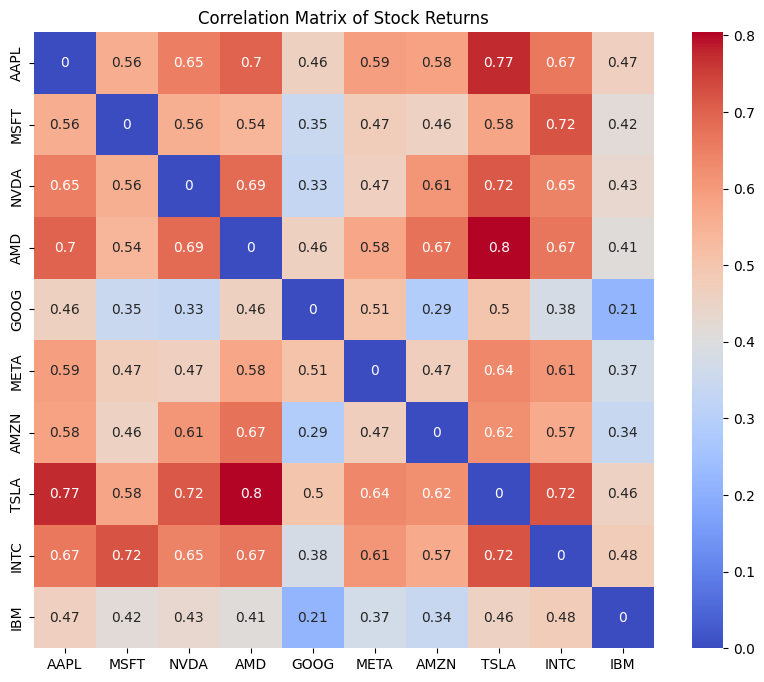

In [216]:
# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(stock_graph(y_train), annot=True, cmap='coolwarm', xticklabels=tickers, yticklabels=tickers)
plt.title('Correlation Matrix of Stock Returns')
plt.show()

**Graph Filter**

In [217]:
def filter_function(h, S, x):
    """
    Preforms graph filtering on the input signal x using the filter coefficients h and the graph Laplacian S.

    ARGS:
    h: filter coefficients (h_1, h_2, ..., h_K)
    S: graph Laplacian
    x: input signal size (B,N)

    RETURNS:
    y: output signal after applying the graph filter
    """

    K = h.shape[0] # number of filter coefficients h_1, h_2, ..., h_K
    B = x.shape[0] # batch size (number of samples processed in parallel)
    N = x.shape[1] # number of nodes (= number of stocks in our case)

    x = x.reshape([B, 1, N]) 
    S = S.reshape([1, N, N])
    z = x

    for k in range(1, K):

        # diffusion step, S^k*x
        x = torch.matmul(x, S)
        xS = x.reshape([B, 1, N]) 

        # concatenate the S^k*x in the tensor z
        z = torch.cat((z, xS), dim=1) 

    # multiply z and h in the concatenation dimension
    y = torch.matmul(z.permute(0, 2, 1).reshape([B, N, K]), h)

    return y

class graph_filter(nn.Module):
    """
    Graph filter layer that applies a learnable graph filter to the input signal.
    """
    def __init__(self, corr, k):
        
        # Initialize parent
        super().__init__()
        
        # Save filter hyperparameters
        self.graph = torch.tensor(corr)
        self.n = corr.shape[0]
        self.k = k
        
        # Define and initialize learnable weights
        self.weight = nn.Parameter(torch.randn(self.k))
        self.reset_parameters()
        
    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.k)
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        return filter_function(self.weight, self.graph, x)

**Graph Perceptron**

In [218]:
class graph_perceptron(nn.Module):
    def __init__(self, gso, k, sigma):
        super().__init__()
        self.gso = torch.tensor(gso)
        self.n = gso.shape[0]
        self.k = k
        self.sigma = sigma
        self.weight = nn.Parameter(torch.randn(self.k))
        self.reset_parameters()
        
    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.k)
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        y = filter_function(self.weight, self.gso, x)
        y = self.sigma(y)
        return y  

**Multi-layer GNN**

In [219]:
class MLGNN(nn.Module):
    def __init__(self, gso, l, k, sigma):
        super().__init__()
        layers = []
        for layer in range(l):
            if layer < l - 1:
                layers.append(graph_perceptron(gso, k[layer], sigma))
            else:
                layers.append(graph_perceptron(gso, k[layer], nn.Identity()))  # no activation on last layer
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        y = self.layers(x)
        return y

**Multiple Feature Filters and GNNs**

In [220]:
def FilterFunctionMulti(h, S, x):
    
    # we assume that the input x PyTorch tensor [B, G, N]
    # the output is y PyTorch tensor [B, F, N]
    # Number of output features
    F = h.shape[0]
    
    # Number of filter taps
    K = h.shape[1]
    
    # Number of input features
    G = h.shape[2]
    
    # Number of nodes
    N = S.shape[1]
    
    # Batch size
    B = x.shape[0]

    # Create concatenation dimension and initialize concatenation tensor z
    x = x.reshape([B, 1, G, N])
    S = S.reshape([1, N, N])
    z = x
    
    # Loop over the number of filter taps
    for k in range(1, K):
        
        # S*x
        x = torch.matmul(x, S)
        
        # Reshape
        xS = x.reshape([B, 1, G, N])
        
        # Concatenate
        z = torch.cat((z, xS), dim=1)
    
    # Multiply by h
    y = torch.matmul(z.permute(0, 3, 1, 2).reshape([B, N, K*G]), 
                     h.reshape([F, K*G]).permute(1, 0)).permute(0, 2, 1)
    return y
    
    
class GraphFilterMulti(nn.Module):
    def __init__(self, gso, k, f_in, f_out):
        super().__init__()
        self.gso = torch.tensor(gso)
        self.n = gso.shape[0]
        self.k = k
        self.f_in = f_in
        self.f_out = f_out
        self.weight = nn.Parameter(torch.randn(self.f_out, self.k, self.f_in))
        self.reset_parameters()
        
    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.f_in * self.k)
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        return FilterFunctionMulti(self.weight, self.gso, x)

In [221]:
class GNNMulti(nn.Module):
    def __init__(self, gso, l, k, f, sigma):
        super().__init__()
        self.gso = torch.tensor(gso)
        self.n = gso.shape[0]
        self.l = l
        self.k = k
        self.f = f
        self.sigma = sigma
        
        gml = []
        for layer in range(l):
            gml.append(GraphFilterMulti(gso, k[layer], f[layer], f[layer+1]))
            if layer < l - 1:  # no activation after last layer
                gml.append(sigma)
        
        self.gml = nn.Sequential(*gml)
        
    def forward(self, x):
        return self.gml(x)

**TESTING**

In [222]:
def train_model(model, x_train, y_train, lr=0.01, epochs=300):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        y_pred = model(x_train)
        loss = criterion(y_pred, y_train)
        losses.append(loss.item())
        loss.backward()
        optimizer.step()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")
        if loss.item() < 1e-6:
            print(f"Early stopping at epoch {epoch+1} with loss {loss.item():.6f}")
            break
    return model, losses

In [223]:
def train_model_multi(model, x_train, y_train, lr=0.001, epochs=300):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(x_train).squeeze(1)  # (B, 1, N) --> (B, N)
        loss = criterion(pred, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")
        if loss.item() < 1e-6:
            print(f"Early stopping at epoch {epoch+1}")
            break
    return model, losses

/var/folders/d0/1nn98jmj4gn_7vzw374_ds4c0000gn/T/ipykernel_99684/2249465692.py:10: RuntimeWarning: invalid value encountered in divide
  return G / np.max(np.abs(eigs))
/var/folders/d0/1nn98jmj4gn_7vzw374_ds4c0000gn/T/ipykernel_99684/281005117.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.graph = torch.tensor(corr)
/var/folders/d0/1nn98jmj4gn_7vzw374_ds4c0000gn/T/ipykernel_99684/3586927298.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.gso = torch.tensor(gso)


Training Graph Filter...
Epoch 10/300, Loss: 0.051319
Epoch 20/300, Loss: 0.003617
Epoch 30/300, Loss: 0.006949
Epoch 40/300, Loss: 0.004444
Epoch 50/300, Loss: 0.001724
Epoch 60/300, Loss: 0.001700
Epoch 70/300, Loss: 0.001211
Epoch 80/300, Loss: 0.001015
Epoch 90/300, Loss: 0.000909
Epoch 100/300, Loss: 0.000834
Epoch 110/300, Loss: 0.000801
Epoch 120/300, Loss: 0.000780
Epoch 130/300, Loss: 0.000770
Epoch 140/300, Loss: 0.000766
Epoch 150/300, Loss: 0.000764
Epoch 160/300, Loss: 0.000763
Epoch 170/300, Loss: 0.000763
Epoch 180/300, Loss: 0.000763
Epoch 190/300, Loss: 0.000763
Epoch 200/300, Loss: 0.000762
Epoch 210/300, Loss: 0.000762
Epoch 220/300, Loss: 0.000762
Epoch 230/300, Loss: 0.000762
Epoch 240/300, Loss: 0.000762
Epoch 250/300, Loss: 0.000762
Epoch 260/300, Loss: 0.000762
Epoch 270/300, Loss: 0.000762
Epoch 280/300, Loss: 0.000762
Epoch 290/300, Loss: 0.000762
Epoch 300/300, Loss: 0.000762


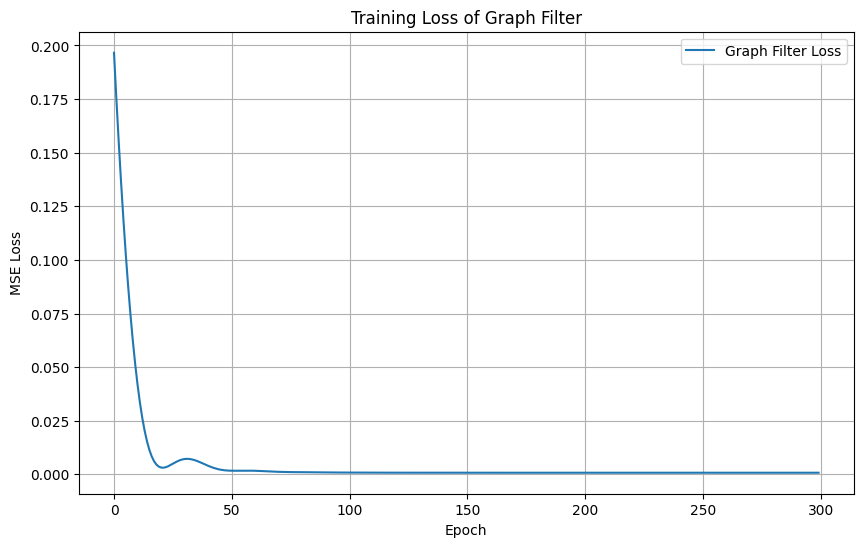

Training Graph Perceptron...
Epoch 10/300, Loss: 0.011741
Epoch 20/300, Loss: 0.006165
Epoch 30/300, Loss: 0.002848
Epoch 40/300, Loss: 0.001241
Epoch 50/300, Loss: 0.000799
Epoch 60/300, Loss: 0.000745
Epoch 70/300, Loss: 0.000754
Epoch 80/300, Loss: 0.000750
Epoch 90/300, Loss: 0.000742
Epoch 100/300, Loss: 0.000740
Epoch 110/300, Loss: 0.000740
Epoch 120/300, Loss: 0.000740
Epoch 130/300, Loss: 0.000740
Epoch 140/300, Loss: 0.000740
Epoch 150/300, Loss: 0.000740
Epoch 160/300, Loss: 0.000740
Epoch 170/300, Loss: 0.000740
Epoch 180/300, Loss: 0.000740
Epoch 190/300, Loss: 0.000740
Epoch 200/300, Loss: 0.000740
Epoch 210/300, Loss: 0.000740
Epoch 220/300, Loss: 0.000740
Epoch 230/300, Loss: 0.000740
Epoch 240/300, Loss: 0.000740
Epoch 250/300, Loss: 0.000740
Epoch 260/300, Loss: 0.000740
Epoch 270/300, Loss: 0.000740
Epoch 280/300, Loss: 0.000740
Epoch 290/300, Loss: 0.000740
Epoch 300/300, Loss: 0.000740


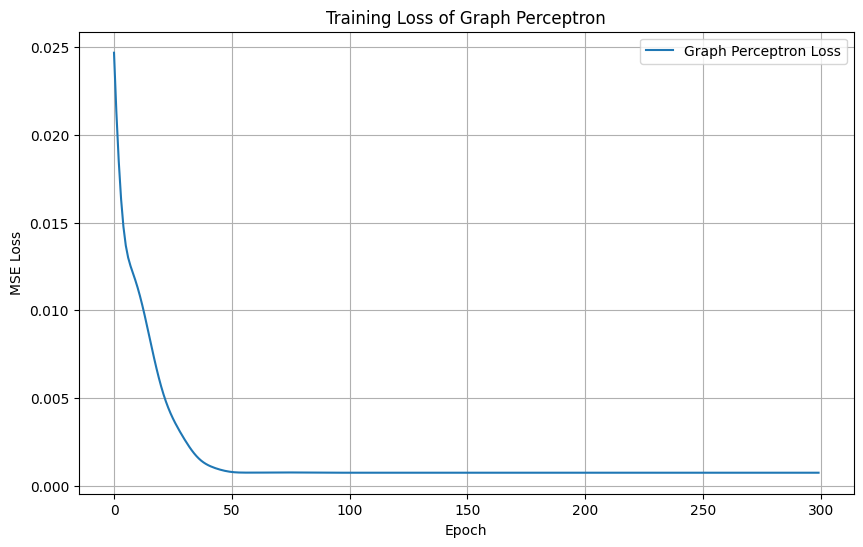

Training MLGNN...
Epoch 10/300, Loss: 0.000844
Epoch 20/300, Loss: 0.000745
Epoch 30/300, Loss: 0.000739
Epoch 40/300, Loss: 0.000740
Epoch 50/300, Loss: 0.000740
Epoch 60/300, Loss: 0.000740
Epoch 70/300, Loss: 0.000740
Epoch 80/300, Loss: 0.000740
Epoch 90/300, Loss: 0.000740
Epoch 100/300, Loss: 0.000740
Epoch 110/300, Loss: 0.000740
Epoch 120/300, Loss: 0.000740
Epoch 130/300, Loss: 0.000740
Epoch 140/300, Loss: 0.000739
Epoch 150/300, Loss: 0.000739
Epoch 160/300, Loss: 0.000739
Epoch 170/300, Loss: 0.000738
Epoch 180/300, Loss: 0.000738
Epoch 190/300, Loss: 0.000738
Epoch 200/300, Loss: 0.000738
Epoch 210/300, Loss: 0.000738
Epoch 220/300, Loss: 0.000738
Epoch 230/300, Loss: 0.000738
Epoch 240/300, Loss: 0.000738
Epoch 250/300, Loss: 0.000738
Epoch 260/300, Loss: 0.000738
Epoch 270/300, Loss: 0.000738
Epoch 280/300, Loss: 0.000738
Epoch 290/300, Loss: 0.000738
Epoch 300/300, Loss: 0.000738


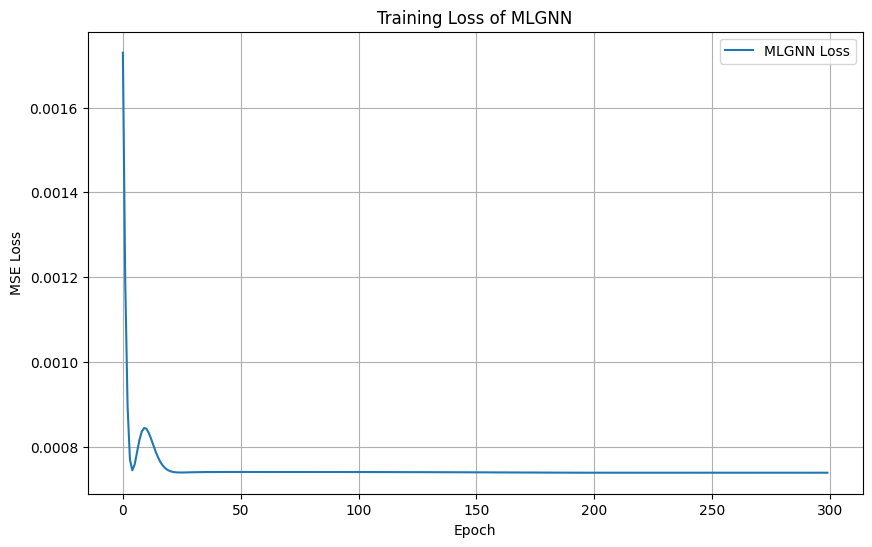

Training Multi Feature Filter...
Epoch 10/300, Loss: 0.209960
Epoch 20/300, Loss: 0.168690
Epoch 30/300, Loss: 0.135676
Epoch 40/300, Loss: 0.109517
Epoch 50/300, Loss: 0.088392
Epoch 60/300, Loss: 0.071203
Epoch 70/300, Loss: 0.057188
Epoch 80/300, Loss: 0.045793
Epoch 90/300, Loss: 0.036571
Epoch 100/300, Loss: 0.029148
Epoch 110/300, Loss: 0.023211
Epoch 120/300, Loss: 0.018492
Epoch 130/300, Loss: 0.014764
Epoch 140/300, Loss: 0.011837
Epoch 150/300, Loss: 0.009548
Epoch 160/300, Loss: 0.007764
Epoch 170/300, Loss: 0.006377
Epoch 180/300, Loss: 0.005295
Epoch 190/300, Loss: 0.004451
Epoch 200/300, Loss: 0.003787
Epoch 210/300, Loss: 0.003263
Epoch 220/300, Loss: 0.002844
Epoch 230/300, Loss: 0.002507
Epoch 240/300, Loss: 0.002234
Epoch 250/300, Loss: 0.002010
Epoch 260/300, Loss: 0.001824
Epoch 270/300, Loss: 0.001670
Epoch 280/300, Loss: 0.001541
Epoch 290/300, Loss: 0.001432
Epoch 300/300, Loss: 0.001340


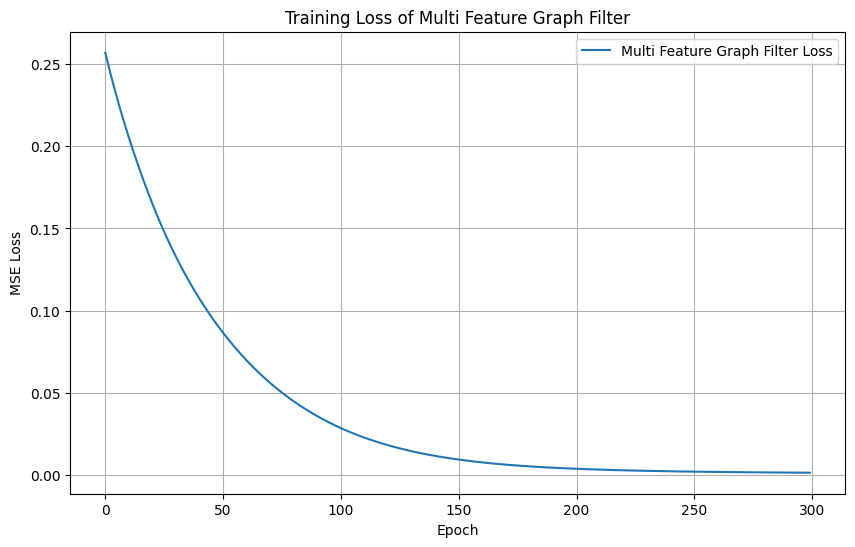

Training Multi Feature GNN...
Epoch 10/300, Loss: 0.006241
Epoch 20/300, Loss: 0.007201
Epoch 30/300, Loss: 0.002740
Epoch 40/300, Loss: 0.002555
Epoch 50/300, Loss: 0.001847
Epoch 60/300, Loss: 0.001639


KeyboardInterrupt: 

In [257]:
corr = stock_graph(y_train)
corr = normalize_graph(corr)
corr = torch.tensor(corr, dtype=torch.float32)

# alternative graph constructions
partial_corr = partial_corr_graph(y_train)
partial_corr = normalize_graph(partial_corr)
partial_corr = torch.tensor(partial_corr, dtype=torch.float32)

thresholded_corr = threshold_graph(corr, threshold=0.5)
thresholded_corr = normalize_graph(thresholded_corr)
thresholded_corr = torch.tensor(thresholded_corr, dtype=torch.float32)

# compute statistics from training data!
x_mean = x_train_tensor.mean(dim=0)
x_std  = x_train_tensor.std(dim=0) + 1e-8

x_train_tensor_norm = (x_train_tensor - x_mean) / x_std
x_test_tensor_norm  = (x_test_tensor  - x_mean) / x_std

x_muli_feature_train = x_train_tensor_norm.unsqueeze(1) # shape [B, 1, N]
x_muli_feature_test = x_test_tensor_norm.unsqueeze(1) # shape [B, 1, N]

K = 3
gf_model = graph_filter(corr, K)
gp_model = graph_perceptron(corr, K, nn.ReLU())
mlgnn_model = MLGNN(corr, l=2, k=[3, 3], sigma=nn.LeakyReLU())
mfgf_model = GraphFilterMulti(corr, k=3, f_in=10, f_out=1)
mfgnn_model = GNNMulti(corr, l=2, k=[3, 3], sigma=nn.LeakyReLU(), f=[10, 32, 1])

mfgnn_model_partial = GNNMulti(thresholded_corr, l=2, k=[3, 3], sigma=nn.LeakyReLU(), f=[10, 32, 1])
mfgnn_model_thresholded = GNNMulti(thresholded_corr, l=2, k=[3, 3], sigma=nn.LeakyReLU(), f=[10, 32, 1])

print("Training Graph Filter...")
gf_model, gf_losses = train_model(gf_model, x_train_tensor_norm, y_train_tensor)
# plot loss per epoch for graph filter
plt.figure(figsize=(10, 6))
plt.plot(gf_losses, label='Graph Filter Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Graph Filter')
plt.legend()
plt.grid()
plt.show()

print("Training Graph Perceptron...")
gp_model, gp_losses = train_model(gp_model, x_train_tensor_norm, y_train_tensor)
# plot loss per epoch for graph perceptron
plt.figure(figsize=(10, 6))
plt.plot(gp_losses, label='Graph Perceptron Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Graph Perceptron')
plt.legend()
plt.grid()
plt.show()

print("Training MLGNN...")
mlgnn_model, mlgnn_losses = train_model(mlgnn_model, x_train_tensor_norm, y_train_tensor)
# plot loss per epoch for MLGNN
plt.figure(figsize=(10, 6))
plt.plot(mlgnn_losses, label='MLGNN Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of MLGNN')
plt.legend()
plt.grid()
plt.show()


print("Training Multi Feature Filter...")
mfgf_model, mfgf_losses = train_model_multi(mfgf_model, x_train_tensor_mf, y_train_tensor_mf)
# plot loss per epoch for multi feature graph filter
plt.figure(figsize=(10, 6))
plt.plot(mfgf_losses, label='Multi Feature Graph Filter Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Multi Feature Graph Filter')
plt.legend()
plt.grid()
plt.show()


print("Training Multi Feature GNN...")
mfgnn_model, mfgnn_losses = train_model_multi(mfgnn_model, x_train_tensor_mf, y_train_tensor_mf)
# plot loss per epoch for multi feature GNN
plt.figure(figsize=(10, 6))
plt.plot(mfgnn_losses, label='Multi Feature GNN Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Multi Feature GNN')
plt.legend()
plt.grid()
plt.show()

# print("Training Multi Feature GNN with Partial Correlation Graph...")
# mfgnn_model_partial, mfgnn_partial_losses = train_model_multi(mfgnn_model_partial, x_train_tensor_mf, y_train_tensor_mf)
# # plot loss per epoch for multi feature GNN with partial correlation graph
# plt.figure(figsize=(10, 6))
# plt.plot(mfgnn_partial_losses, label='Multi Feature GNN with Partial Correlation Graph Loss')
# plt.xlabel('Epoch')
# plt.ylabel('MSE Loss')
# plt.title('Training Loss of Multi Feature GNN with Partial Correlation Graph')
# plt.legend()
# plt.grid()
# plt.show()  

# print("Training Multi Feature GNN with Thresholded Correlation Graph...")
# mfgnn_model_thresholded, mfgnn_thresholded_losses = train_model_multi(mfgnn_model_thresholded, x_train_tensor_mf, y_train_tensor_mf)
# # plot loss per epoch for multi feature GNN with thresholded correlation graph
# plt.figure(figsize=(10, 6))
# plt.plot(mfgnn_thresholded_losses, label='Multi Feature GNN with Thresholded Correlation Graph Loss')
# plt.xlabel('Epoch')
# plt.ylabel('MSE Loss')
# plt.title('Training Loss of Multi Feature GNN with Thresholded Correlation Graph')
# plt.legend()
# plt.grid()
# plt.show()


=== Test Results ===
Graph Filter Test Loss: 4.518760
Graph Perceptron Test Loss: 4.248738
MLGNN Test Loss: 0.058198
Multi Feature Graph Filter Test Loss: 0.001029
Multi Feature GNN Test Loss: 0.000850


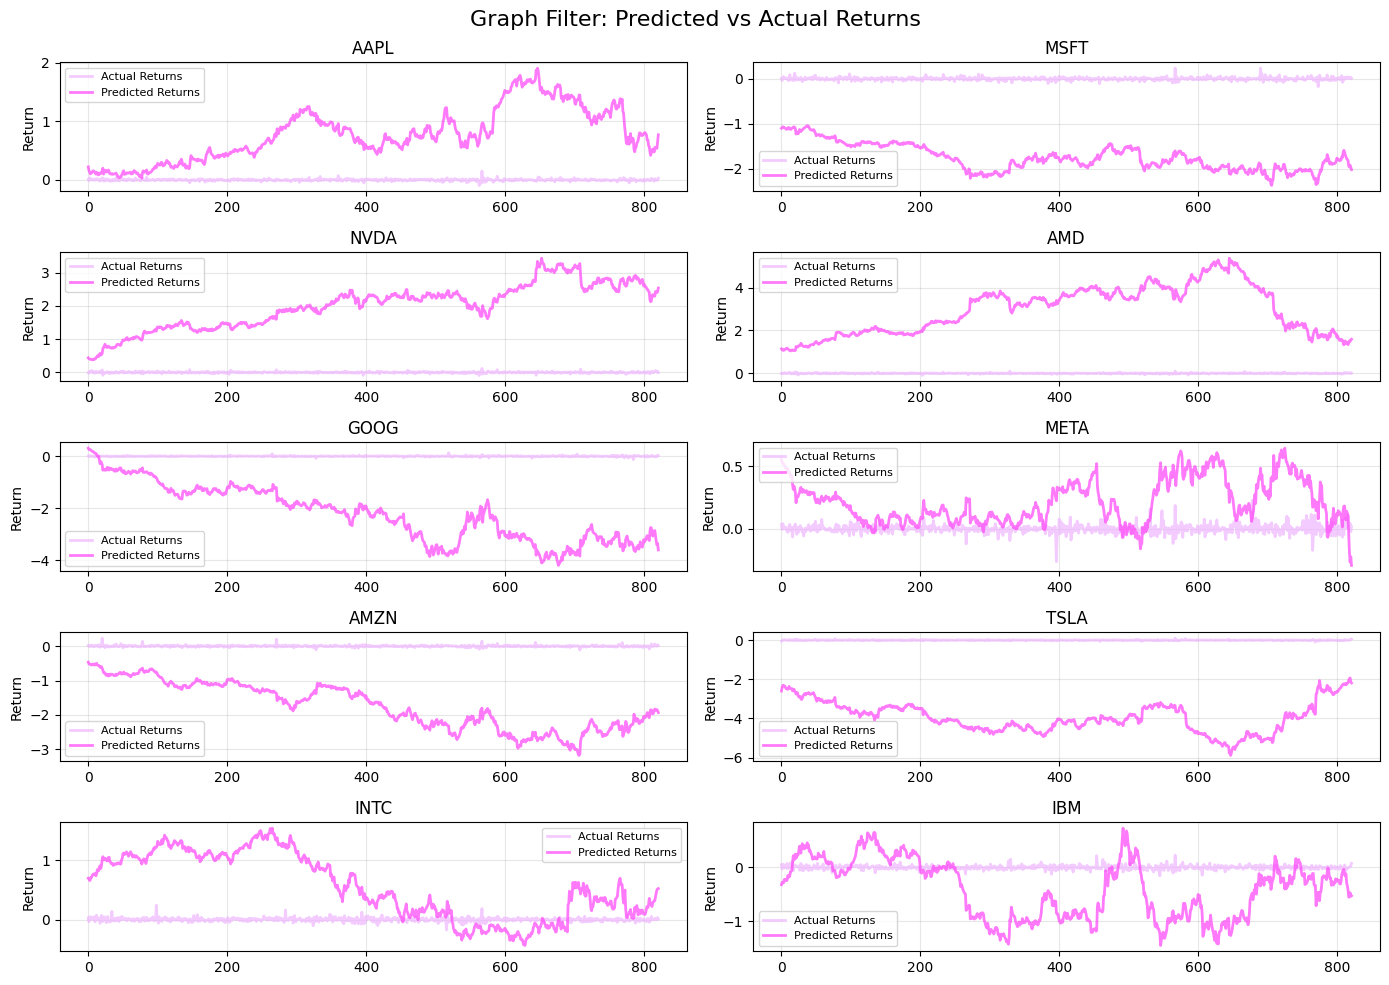

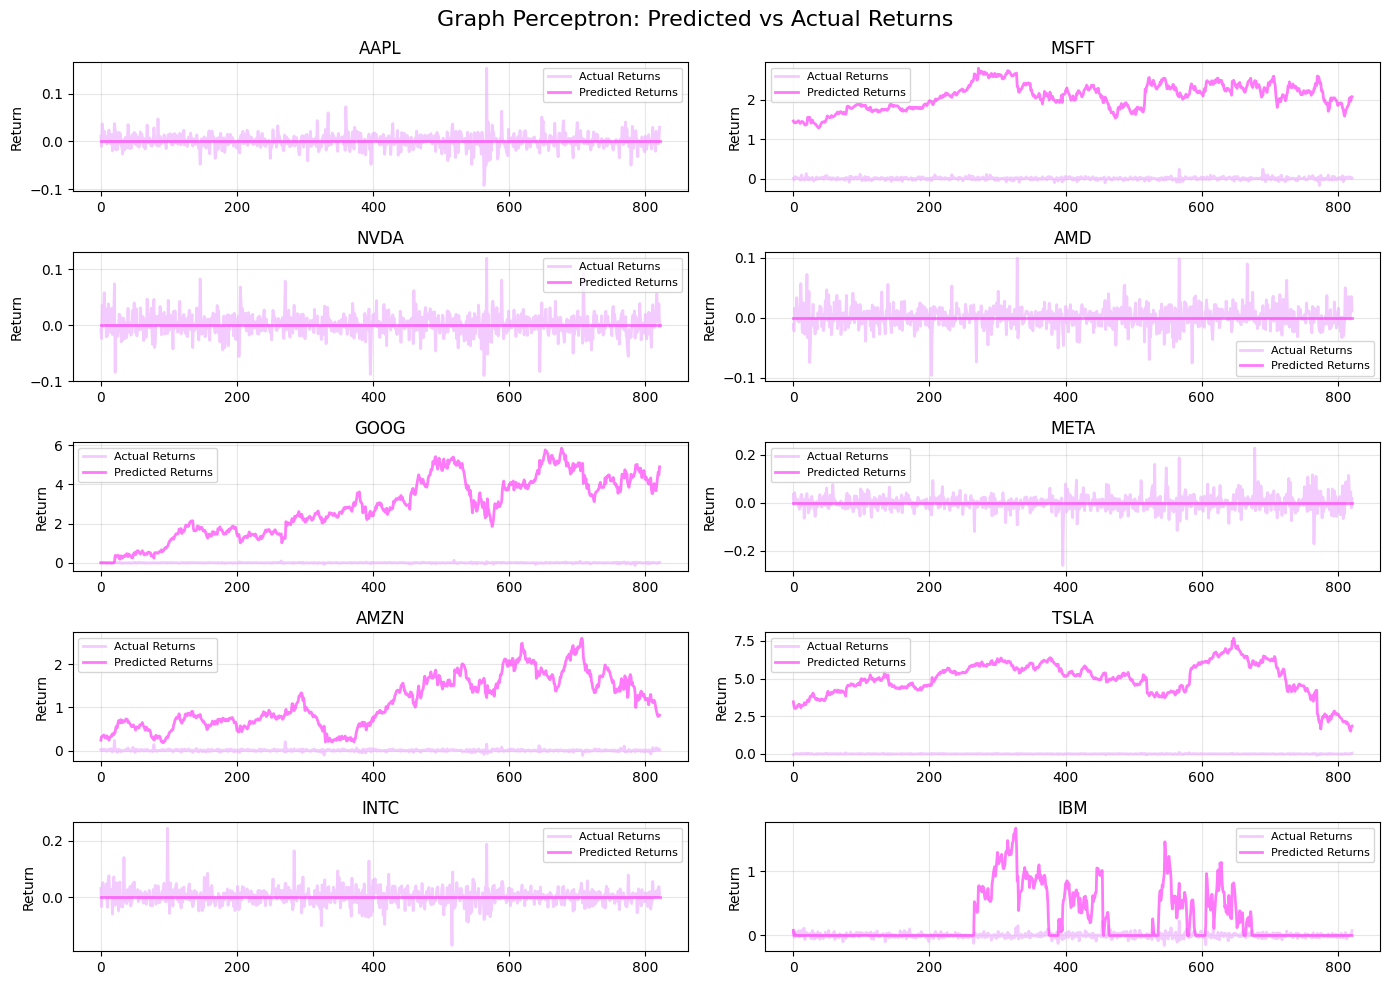

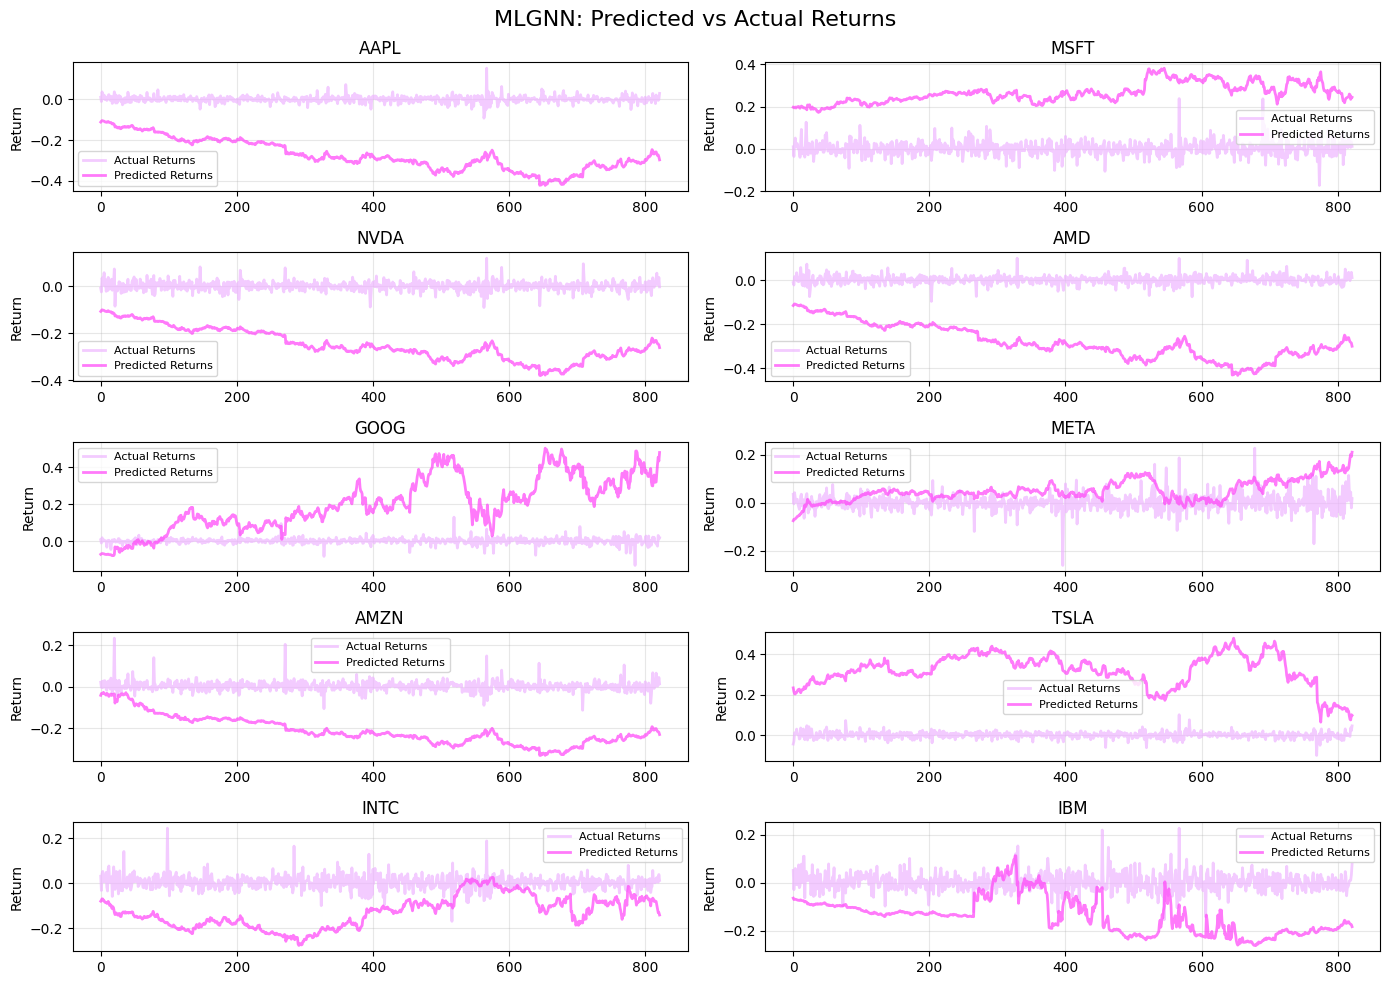

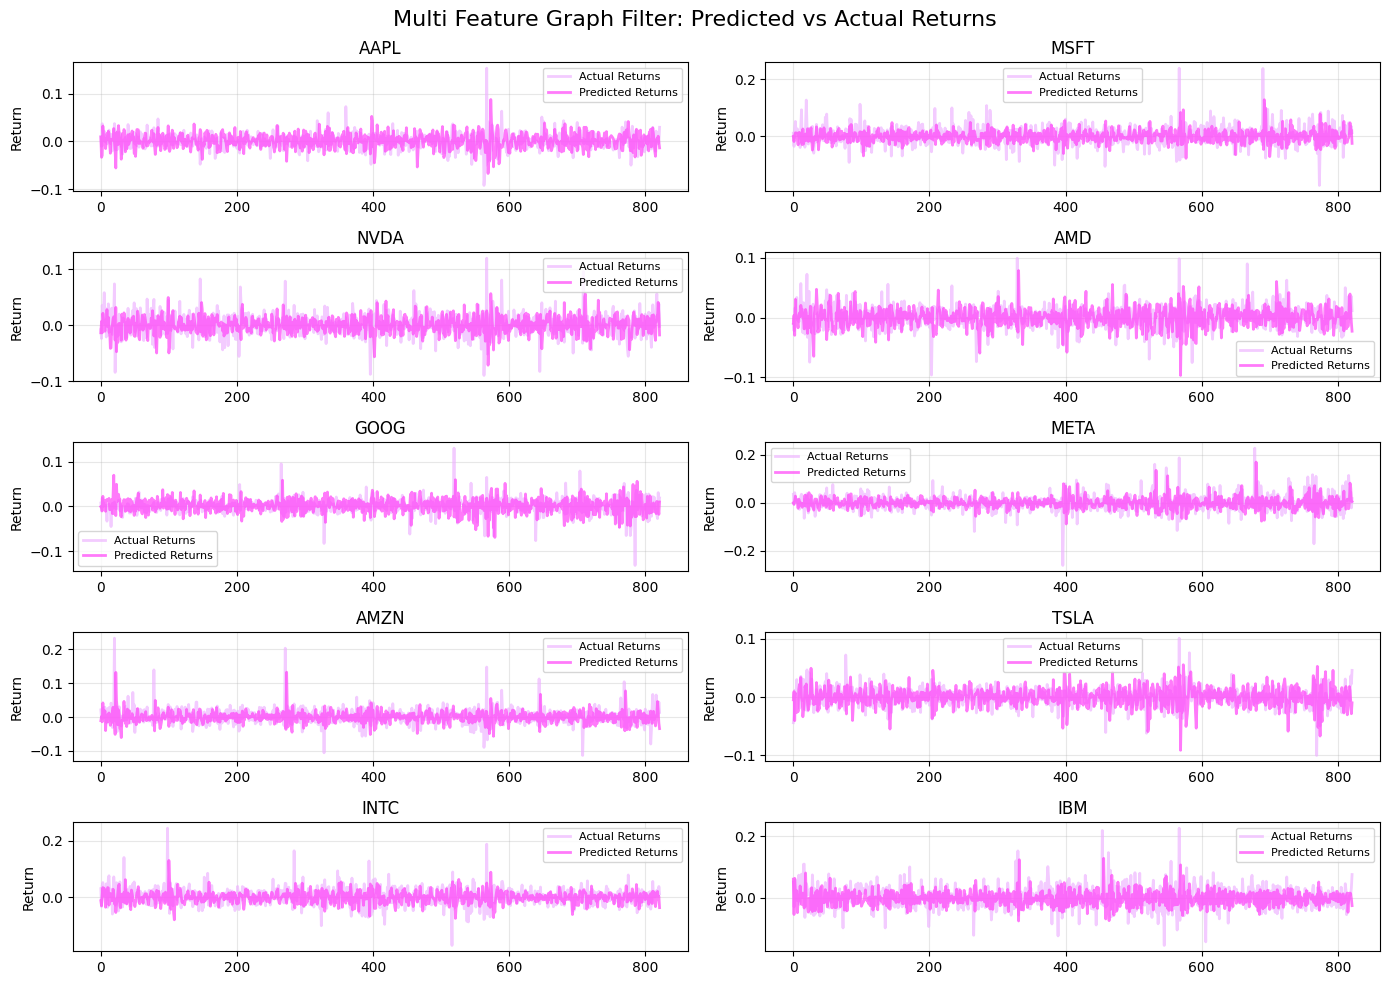

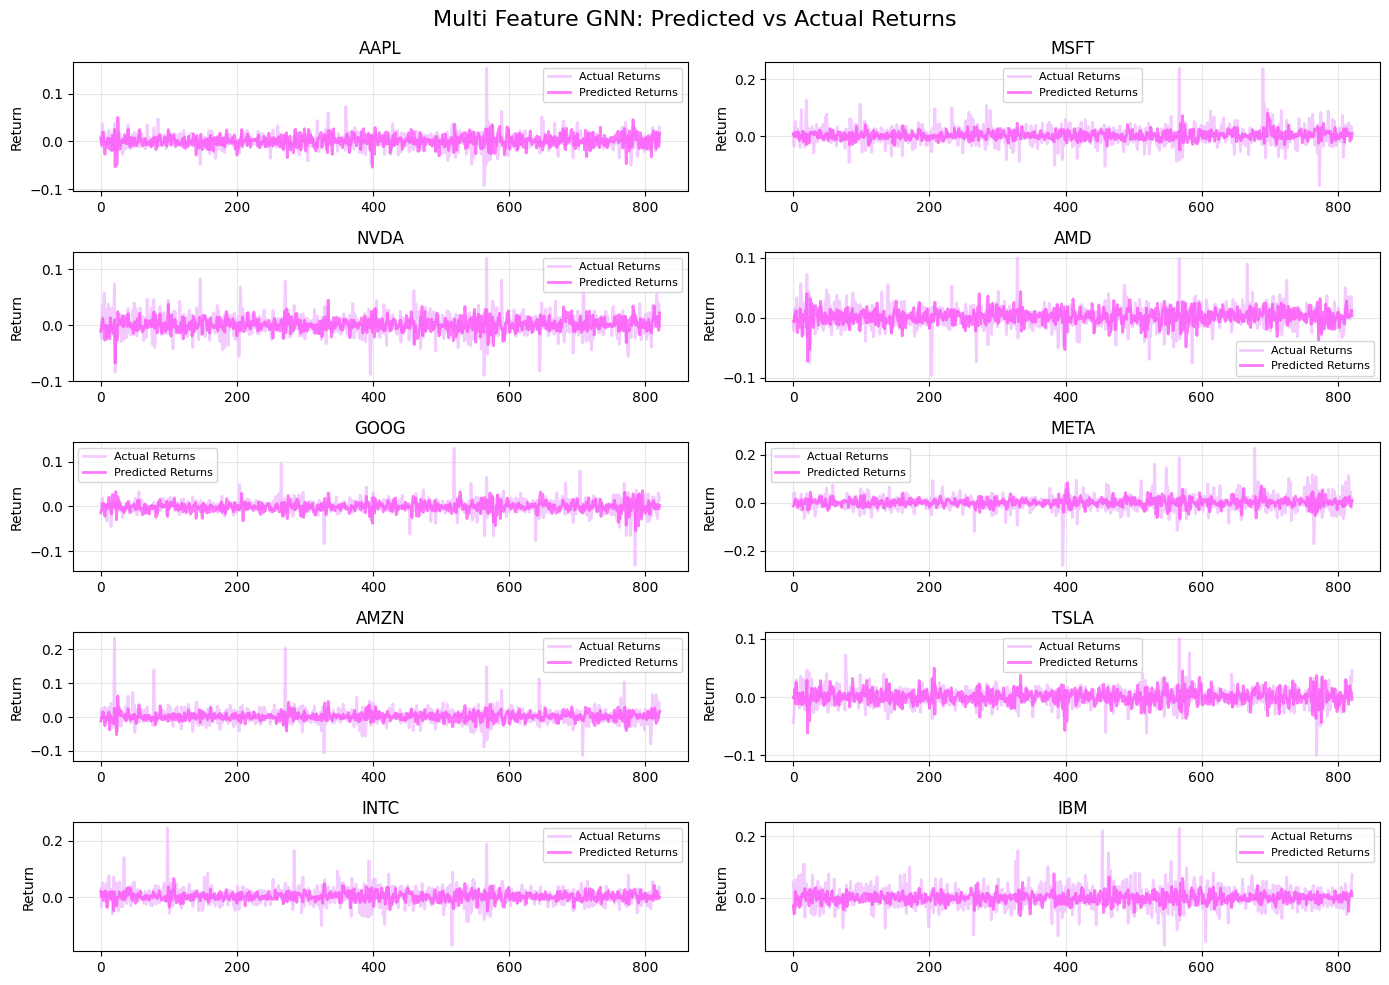

In [225]:
pink = '#ff42f8' 
purple = '#eeb5ff'  

# Evaluate models on test data
criterion = nn.MSELoss()

# Make predictions with both models
with torch.no_grad():
    gf_pred = gf_model(x_test_tensor)
    gp_pred = gp_model(x_test_tensor)
    mlgnn_pred = mlgnn_model(x_test_tensor)
    mfgf_pred = mfgf_model(x_test_tensor_mf).squeeze(1) # reshape from [B, 1, N] to [B, N]
    mfgnn_pred = mfgnn_model(x_test_tensor_mf).squeeze(1) # reshape from [B, 1, N] to [B, N]
    
    # Compute test loss
    gf_test_loss = criterion(gf_pred, y_test_tensor)
    gp_test_loss = criterion(gp_pred, y_test_tensor)
    mlgnn_test_loss = criterion(mlgnn_pred, y_test_tensor)
    mfgf_test_loss = criterion(mfgf_pred, y_test_tensor_mf)
    mfgnn_test_loss = criterion(mfgnn_pred, y_test_tensor_mf)

print(f"\n=== Test Results ===")
print(f"Graph Filter Test Loss: {gf_test_loss.item():.6f}")
print(f"Graph Perceptron Test Loss: {gp_test_loss.item():.6f}")
print(f"MLGNN Test Loss: {mlgnn_test_loss.item():.6f}")
print(f"Multi Feature Graph Filter Test Loss: {mfgf_test_loss.item():.6f}")
print(f"Multi Feature GNN Test Loss: {mfgnn_test_loss.item():.6f}")

# Plot predicted vs actual returns per stock for Graph Filter
plt.figure(figsize=(14, 10))
plt.suptitle('Graph Filter: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=purple)
    plt.plot(gf_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=pink)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot predicted vs actual returns per stock for Graph Perceptron
plt.figure(figsize=(14, 10))
plt.suptitle('Graph Perceptron: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=purple)
    plt.plot(gp_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=pink)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot predicted vs actual returns per stock for MLGNN
plt.figure(figsize=(14, 10))
plt.suptitle('MLGNN: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=purple)
    plt.plot(mlgnn_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=pink)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot predicted vs actual returns per stock for Mutli Feature Graph Filter
plt.figure(figsize=(14, 10))
plt.suptitle('Multi Feature Graph Filter: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=purple)
    plt.plot(mfgf_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=pink)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot predicted vs actual returns per stock for Mutli Feature GNN
plt.figure(figsize=(14, 10))
plt.suptitle('Multi Feature GNN: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=purple)
    plt.plot(mfgnn_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=pink)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Model Evaluation**

In [241]:
from scipy.stats import pearsonr

with torch.no_grad():
    gf_pred    = gf_model(x_test_tensor_norm)
    gp_pred    = gp_model(x_test_tensor_norm)
    mlgnn_pred = mlgnn_model(x_test_tensor_norm)
    mfgf_pred  = mfgf_model(x_test_tensor_mf).squeeze(1)
    mfgnn_pred = mfgnn_model(x_test_tensor_mf).squeeze(1)


def evaluate_metrics(y_true, y_pred):
    y_true_np = y_true.detach().cpu().numpy()
    y_pred_np = y_pred.detach().cpu().numpy()

    mse = np.mean((y_true_np - y_pred_np) ** 2)
    mae = np.mean(np.abs(y_true_np - y_pred_np))
    directional_acc = np.mean(np.sign(y_true_np) == np.sign(y_pred_np))
    
    # correlation per stock, then average
    corrs = [pearsonr(y_true_np[:, i], y_pred_np[:, i])[0] for i in range(y_true_np.shape[1])]
    avg_corr = np.mean(corrs)
    
    return {
        "mse": float(mse),
        "mae": float(mae),
        "directional_accuracy": float(directional_acc),
        "avg_correlation": float(avg_corr)
    }

results = {
    "Graph Filter":       evaluate_metrics(y_test_tensor,  gf_pred),
    "Graph Perceptron":   evaluate_metrics(y_test_tensor,  gp_pred),
    "MLGNN":              evaluate_metrics(y_test_tensor,  mlgnn_pred),
    "MF Graph Filter":    evaluate_metrics(y_test_tensor_mf,   mfgf_pred),
    "MF GNN":             evaluate_metrics(y_test_tensor_mf,   mfgnn_pred),
}

summary = pd.DataFrame(results).T
summary.index.name = "model"
summary = summary.reset_index()
summary.columns = ["model", "mse", "mae", "directional_accuracy", "avg_correlation"]
print(summary.to_string(index=False))

           model      mse      mae  directional_accuracy  avg_correlation
    Graph Filter 0.008019 0.056277              0.498540         0.010152
Graph Perceptron 0.010774 0.047978              0.209124              NaN
           MLGNN 0.000747 0.018722              0.484185         0.000428
 MF Graph Filter 0.001029 0.022986              0.490024         0.006097
          MF GNN 0.000850 0.020357              0.501217         0.014534


/var/folders/d0/1nn98jmj4gn_7vzw374_ds4c0000gn/T/ipykernel_99684/1116087469.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corrs = [pearsonr(y_true_np[:, i], y_pred_np[:, i])[0] for i in range(y_true_np.shape[1])]


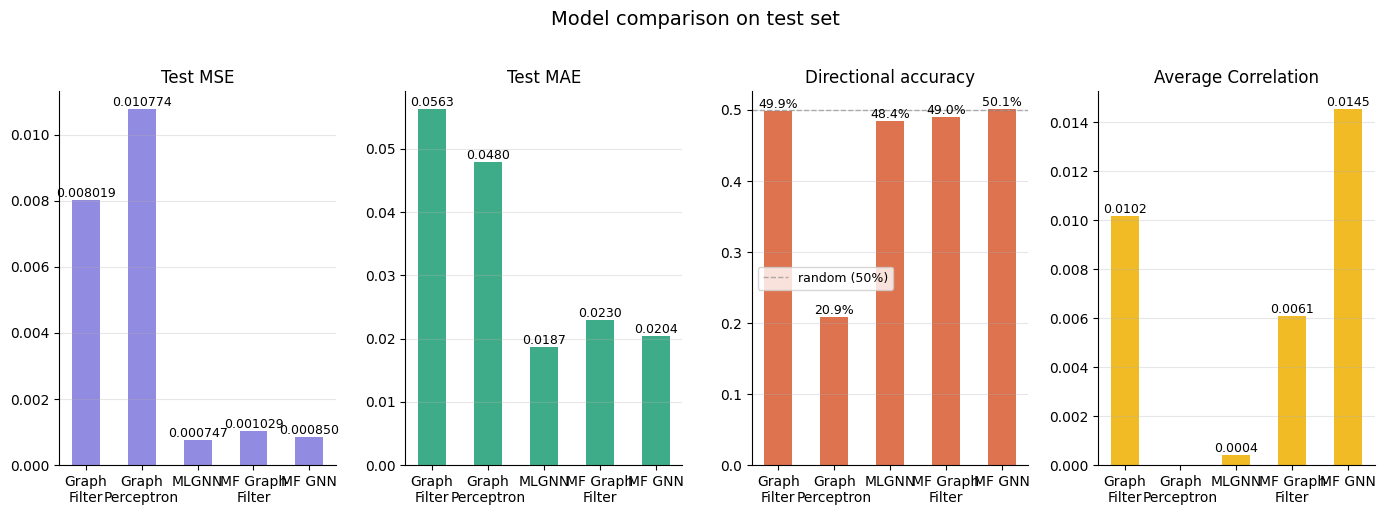

In [245]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Graph\nFilter', 'Graph\nPerceptron', 'MLGNN', 'MF Graph\nFilter', 'MF GNN']

x = np.arange(len(models))
w = 0.25
purple = '#7F77DD'
teal   = '#1D9E75'
coral  = '#D85A30'

fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for ax, vals, label, color, fmt in zip(
    axes,
    [summary['mse'], summary['mae'], summary['directional_accuracy'], summary['avg_correlation']],
    ['Test MSE', 'Test MAE', 'Directional accuracy', 'Average Correlation'],
    [purple, teal, coral, '#EFAF00'],
    ['.6f', '.4f', '.1%', '.4f']
):
    bars = ax.bar(x, vals, color=color, alpha=0.85, width=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10)
    ax.set_title(label, fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                format(v, fmt), ha='center', va='bottom', fontsize=9)

# dashed line at 50% for directional accuracy
axes[2].axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='random (50%)')
axes[2].legend(fontsize=9)

plt.suptitle('Model comparison on test set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

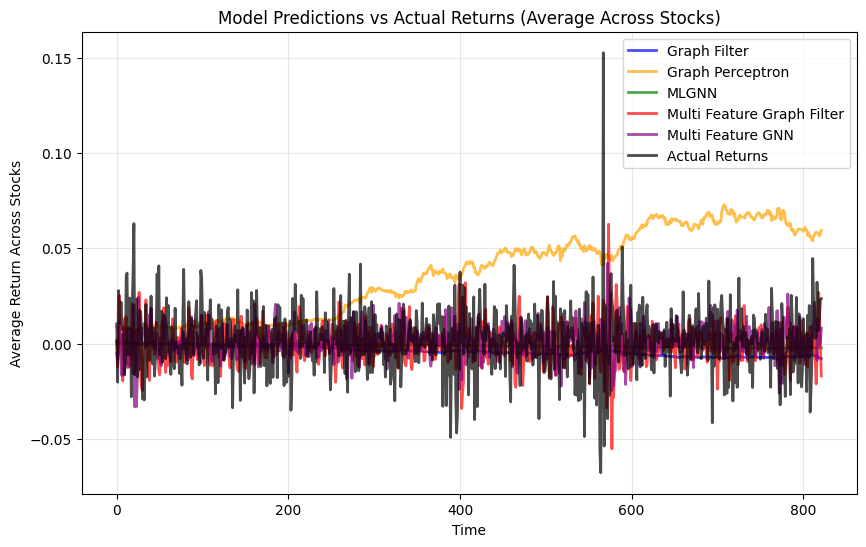

In [246]:
# Optional: plot deltas vs baseline
plt.figure(figsize=(10, 6))
plt.plot(gf_pred.mean(dim=1).numpy(), label='Graph Filter', linewidth=2, alpha=0.7, color='blue')
plt.plot(gp_pred.mean(dim= 1).numpy(), label='Graph Perceptron', linewidth=2, alpha=0.7, color='orange')
plt.plot(mlgnn_pred.mean(dim=1).numpy(), label='MLGNN', linewidth=2, alpha=0.7, color='green')
plt.plot(mfgf_pred.mean(dim=1).numpy(), label='Multi Feature Graph Filter', linewidth=2, alpha=0.7, color='red')
plt.plot(mfgnn_pred.mean(dim=1).numpy(), label='Multi Feature GNN', linewidth=2, alpha=0.7, color='purple')
plt.plot(y_test_tensor.mean(dim=1).numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color='black')
plt.xlabel('Time')
plt.ylabel('Average Return Across Stocks')
plt.title('Model Predictions vs Actual Returns (Average Across Stocks)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Multi-feature part

This part adds a multi-feature GNN model so that we can see the plan from the presentation: past 5 days, moving-average style features, and volatility. 

In [229]:
def build_feature_panel(close_df, lag_days=5, ma_windows=(5, 10), vol_windows=(5,)):
    """
    Build node features for each stock using only information available up to time t.
    Target is next-day return r_{t+1}.

    Returns
    -------
    X : np.ndarray of shape (B, F, N)
        B = number of samples
        F = number of engineered features
        N = number of stocks
    Y : np.ndarray of shape (B, N)
        Next-day returns for each stock
    feature_names : list[str]
        Names of feature channels in X
    valid_dates : pd.Index
        Dates corresponding to each sample
    returns_df : pd.DataFrame
        Daily returns aligned to the original close_df index
    """
    close_df = close_df.copy()
    returns_df = close_df.pct_change()

    feature_frames = []
    feature_names = []

    # 1) Lagged returns: r_t, r_{t-1}, ..., r_{t-lag_days+1}
    for lag in range(lag_days):
        feat = returns_df.shift(lag)
        feature_frames.append(feat)
        feature_names.append(f"ret_lag_{lag+1}")

    # 2) Moving-average gap features on prices
    for w in ma_windows:
        ma = close_df.rolling(w).mean()
        feat = (close_df / ma) - 1.0
        feature_frames.append(feat)
        feature_names.append(f"price_vs_ma_{w}")

    # 3) Rolling volatility of returns
    for w in vol_windows:
        feat = returns_df.rolling(w).std()
        feature_frames.append(feat)
        feature_names.append(f"vol_{w}")

    # Optional momentum feature: mean recent return
    for w in ma_windows:
        feat = returns_df.rolling(w).mean()
        feature_frames.append(feat)
        feature_names.append(f"ret_mean_{w}")

    # Next-day target
    target_df = returns_df.shift(-1)

    # Keep only dates where every feature and target exists
    valid_mask = target_df.notna().all(axis=1)
    for feat in feature_frames:
        valid_mask &= feat.notna().all(axis=1)

    valid_dates = close_df.index[valid_mask]

    X = np.stack([feat.loc[valid_dates].values for feat in feature_frames], axis=1)  # (B,F,N)
    Y = target_df.loc[valid_dates].values  # (B,N)

    return X, Y, feature_names, valid_dates, returns_df


def train_test_split_panel(close_df, split_date="2023-01-01", lag_days=5, ma_windows=(5, 10), vol_windows=(5,)):
    X, Y, feature_names, valid_dates, returns_df = build_feature_panel(
        close_df, lag_days=lag_days, ma_windows=ma_windows, vol_windows=vol_windows
    )

    train_mask = valid_dates < pd.Timestamp(split_date)
    test_mask = valid_dates >= pd.Timestamp(split_date)

    X_train = X[train_mask]
    Y_train = Y[train_mask]
    X_test = X[test_mask]
    Y_test = Y[test_mask]

    train_dates = valid_dates[train_mask]
    test_dates = valid_dates[test_mask]

    return X_train, Y_train, X_test, Y_test, feature_names, train_dates, test_dates, returns_df


def standardize_panel(X_train, X_test, eps=1e-8):
    """
    Standardize each feature channel using train-set statistics only.
    X shapes: (B,F,N)
    """
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + eps

    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std
    return X_train_std, X_test_std, mean, std


In [230]:

# -----------------------------
# Multi-feature GNN model
# -----------------------------
class MultiFeatureGraphFilter(nn.Module):
    def __init__(self, gso, in_features, k, hidden_dim=16, activation=nn.ReLU()):
        super().__init__()
        self.gso = torch.tensor(gso, dtype=torch.float32) if not torch.is_tensor(gso) else gso.float()
        self.in_features = in_features
        self.k = k
        self.activation = activation

        # One k-hop filter per input feature
        self.filter_weights = nn.Parameter(torch.empty(in_features, k))
        nn.init.xavier_uniform_(self.filter_weights)

        # Mix features node-wise after graph filtering
        self.feature_mixer = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            activation,
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        """
        x: (B, F, N)
        returns: (B, N)
        """
        B, F, N = x.shape
        outputs = []

        for f in range(F):
            xf = x[:, f, :]                          # (B,N)
            yf = filter_function(self.filter_weights[f], self.gso, xf)  # (B,N)
            outputs.append(yf.unsqueeze(1))         # (B,1,N)

        h = torch.cat(outputs, dim=1)               # (B,F,N)
        h = h.permute(0, 2, 1)                      # (B,N,F)
        y = self.feature_mixer(h).squeeze(-1)       # (B,N)
        return y


def evaluate_metrics(y_true, y_pred):
    y_true_np = y_true.detach().cpu().numpy()
    y_pred_np = y_pred.detach().cpu().numpy()

    mse = np.mean((y_true_np - y_pred_np) ** 2)
    mae = np.mean(np.abs(y_true_np - y_pred_np))
    directional_acc = np.mean(np.sign(y_true_np) == np.sign(y_pred_np))
    return {
        "mse": float(mse),
        "mae": float(mae),
        "directional_accuracy": float(directional_acc)
    }


def train_and_evaluate_multifeature_model(
    close_df,
    selected_features,
    split_date="2023-01-01",
    lag_days=5,
    ma_windows=(5, 10),
    vol_windows=(5,),
    lr=0.01,
    epochs=300,
    k=3,
    hidden_dim=16
):
    # Build full feature panel
    X_train, Y_train, X_test, Y_test, feature_names, train_dates, test_dates, returns_df = train_test_split_panel(
        close_df, split_date=split_date, lag_days=lag_days, ma_windows=ma_windows, vol_windows=vol_windows
    )

    # Select subset of features by name
    feature_idx = [feature_names.index(name) for name in selected_features]
    X_train = X_train[:, feature_idx, :]
    X_test = X_test[:, feature_idx, :]

    # Standardize
    X_train, X_test, _, _ = standardize_panel(X_train, X_test)

    # Graph built from train returns only
    train_returns_df = returns_df.loc[train_dates]
    corr = stock_graph(train_returns_df.dropna().values)
    corr = normalize_graph(corr)
    corr = torch.tensor(corr, dtype=torch.float32)

    # Tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

    # Model
    model = MultiFeatureGraphFilter(
        corr, in_features=len(selected_features), k=k, hidden_dim=hidden_dim, activation=nn.ReLU()
    )

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train_tensor)
        loss = criterion(pred, Y_train_tensor)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_tensor)

    metrics = evaluate_metrics(Y_test_tensor, test_pred)

    return {
        "model": model,
        "train_losses": train_losses,
        "test_pred": test_pred,
        "y_test": Y_test_tensor,
        "metrics": metrics,
        "selected_features": selected_features,
        "test_dates": test_dates
    }


In [231]:

# -----------------------------
# Feature sets to compare
# -----------------------------
all_close = yf.download(tickers, start="2018-01-01")["Close"].dropna()

feature_sets = {
    "baseline_ret_lag_1": ["ret_lag_1"],
    "past_5_returns": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5"],
    "past_5_plus_ma": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                       "price_vs_ma_5", "price_vs_ma_10"],
    "past_5_plus_vol": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                        "vol_5"],
    "all_features": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                     "price_vs_ma_5", "price_vs_ma_10", "vol_5", "ret_mean_5", "ret_mean_10"]
}

results = {}
summary_rows = []

for name, feat_list in feature_sets.items():
    print(f"\nRunning: {name}")
    out = train_and_evaluate_multifeature_model(
        all_close,
        selected_features=feat_list,
        split_date="2023-01-01",
        lag_days=5,
        ma_windows=(5, 10),
        vol_windows=(5,),
        lr=0.01,
        epochs=300,
        k=3,
        hidden_dim=16
    )
    results[name] = out
    summary_rows.append({
        "feature_set": name,
        "num_features": len(feat_list),
        "mse": out["metrics"]["mse"],
        "mae": out["metrics"]["mae"],
        "directional_accuracy": out["metrics"]["directional_accuracy"]
    })

results_df = pd.DataFrame(summary_rows).sort_values("mse").reset_index(drop=True)
print("\n=== Multi-feature comparison ===")
print(results_df)


[*********************100%***********************]  10 of 10 completed



Running: baseline_ret_lag_1

Running: past_5_returns

Running: past_5_plus_ma

Running: past_5_plus_vol

Running: all_features

=== Multi-feature comparison ===
          feature_set  num_features       mse       mae  directional_accuracy
0  baseline_ret_lag_1             1  0.000680  0.017371              0.533820
1     past_5_plus_vol             6  0.000685  0.017491              0.516545
2      past_5_plus_ma             7  0.000689  0.017548              0.502433
3        all_features            10  0.000690  0.017669              0.499027
4      past_5_returns             5  0.000692  0.017548              0.505474


,feature_set,num_features,mse,mae,directional_accuracy
0,baseline_ret_lag_1,1,0.000680,0.017371,0.533820
1,past_5_plus_vol,6,0.000685,0.017491,0.516545
2,past_5_plus_ma,7,0.000689,0.017548,0.502433
3,all_features,10,0.000690,0.017669,0.499027
4,past_5_returns,5,0.000692,0.017548,0.505474


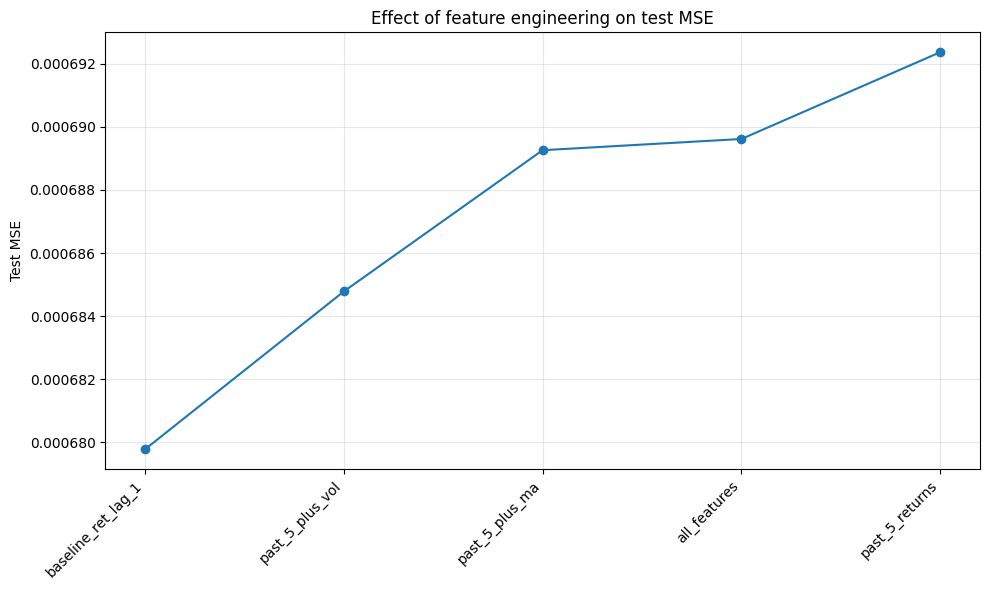

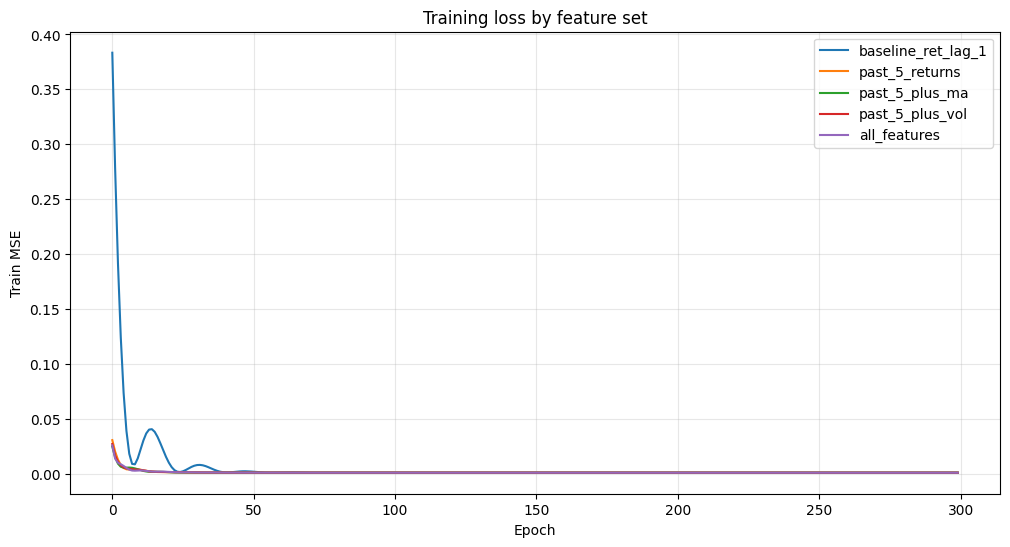

In [232]:

# Plot comparison table and training curves
display(results_df)

plt.figure(figsize=(10, 6))
plt.plot(results_df["feature_set"], results_df["mse"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test MSE")
plt.title("Effect of feature engineering on test MSE")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for name, out in results.items():
    plt.plot(out["train_losses"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.title("Training loss by feature set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Best feature set: baseline_ret_lag_1
['ret_lag_1']
{'mse': 0.0006797775276936591, 'mae': 0.017371075227856636, 'directional_accuracy': 0.5338199513381995}


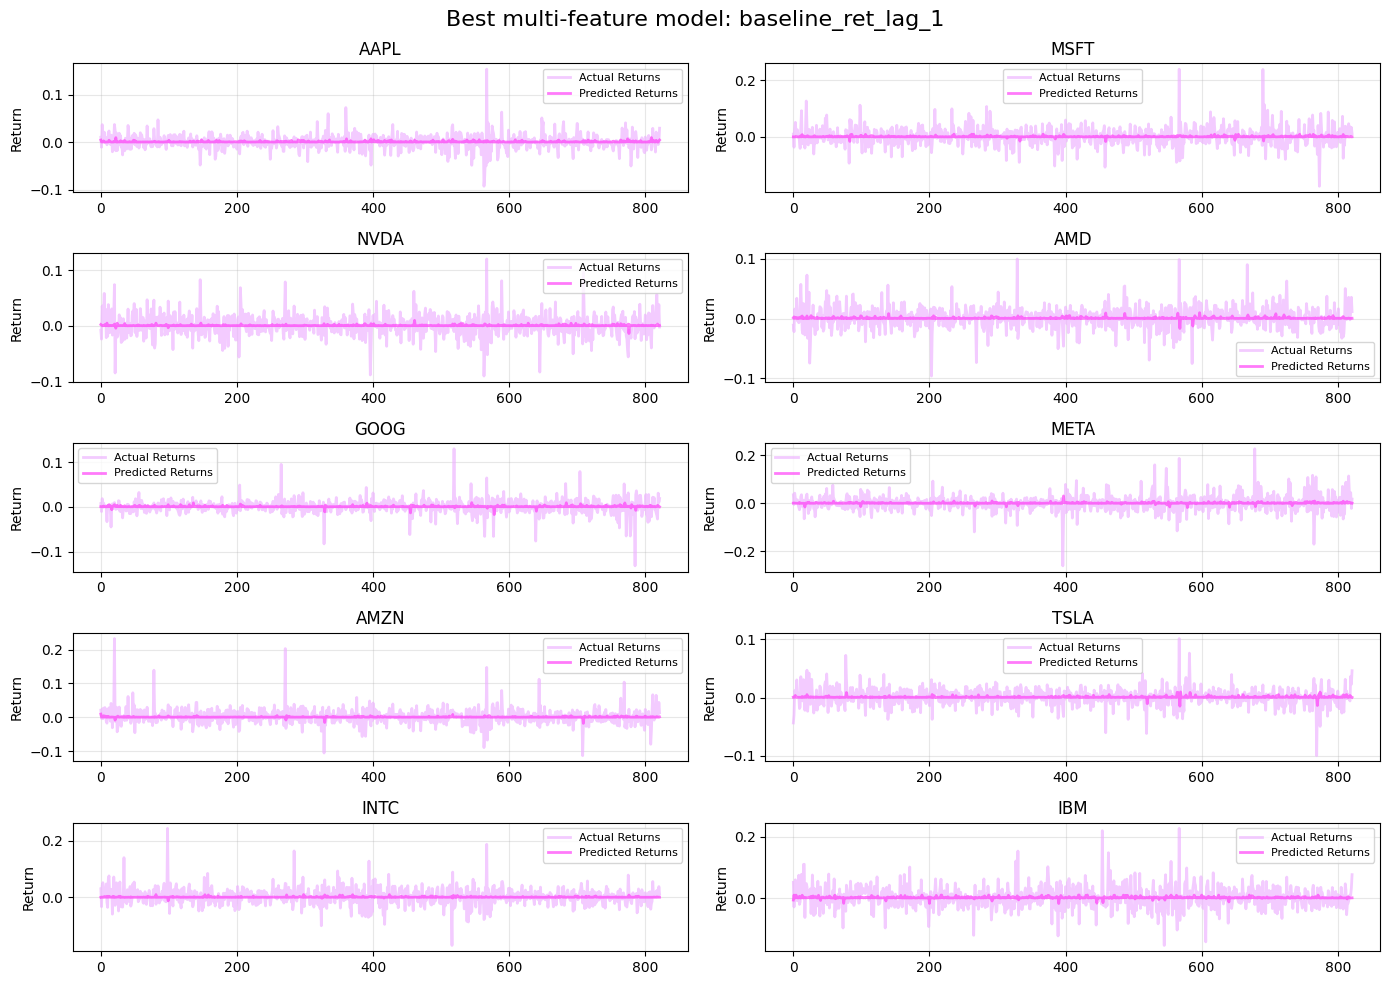

In [233]:
pink = '#ff42f8' 
purple = '#eeb5ff'  

# Example: inspect best model predictions stock-by-stock
best_name = results_df.iloc[0]["feature_set"]
best_out = results[best_name]

print(f"Best feature set: {best_name}")
print(best_out["selected_features"])
print(best_out["metrics"])

plt.figure(figsize=(14, 10))
plt.suptitle(f"Best multi-feature model: {best_name}", fontsize=16)

best_pred = best_out["test_pred"].detach().cpu().numpy()
best_true = best_out["y_test"].detach().cpu().numpy()

for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i + 1)
    plt.plot(best_true[:, i], label="Actual Returns", linewidth=2, alpha=0.7, color=purple)
    plt.plot(best_pred[:, i], label="Predicted Returns", linewidth=2, alpha=0.7, color=pink)
    plt.title(ticker)
    plt.ylabel("Return")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [234]:

# Optional: direct deltas relative to the simplest baseline
baseline_mse = results["baseline_ret_lag_1"]["metrics"]["mse"]
baseline_mae = results["baseline_ret_lag_1"]["metrics"]["mae"]
baseline_dir = results["baseline_ret_lag_1"]["metrics"]["directional_accuracy"]

delta_df = results_df.copy()
delta_df["mse_change_vs_baseline"] = delta_df["mse"] - baseline_mse
delta_df["mae_change_vs_baseline"] = delta_df["mae"] - baseline_mae
delta_df["dir_acc_change_vs_baseline"] = delta_df["directional_accuracy"] - baseline_dir

print(delta_df.sort_values("mse_change_vs_baseline"))
display(delta_df.sort_values("mse_change_vs_baseline"))


          feature_set  num_features       mse       mae  directional_accuracy  \
0  baseline_ret_lag_1             1  0.000680  0.017371              0.533820   
1     past_5_plus_vol             6  0.000685  0.017491              0.516545   
2      past_5_plus_ma             7  0.000689  0.017548              0.502433   
3        all_features            10  0.000690  0.017669              0.499027   
4      past_5_returns             5  0.000692  0.017548              0.505474   

   mse_change_vs_baseline  mae_change_vs_baseline  dir_acc_change_vs_baseline  
0                0.000000                0.000000                    0.000000  
1                0.000005                0.000120                   -0.017275  
2                0.000009                0.000177                   -0.031387  
3                0.000010                0.000298                   -0.034793  
4                0.000013                0.000177                   -0.028345  


,feature_set,num_features,mse,mae,directional_accuracy,mse_change_vs_baseline,mae_change_vs_baseline,dir_acc_change_vs_baseline
0,baseline_ret_lag_1,1,0.000680,0.017371,0.533820,0.000000,0.000000,0.000000
1,past_5_plus_vol,6,0.000685,0.017491,0.516545,0.000005,0.000120,-0.017275
2,past_5_plus_ma,7,0.000689,0.017548,0.502433,0.000009,0.000177,-0.031387
3,all_features,10,0.000690,0.017669,0.499027,0.000010,0.000298,-0.034793
4,past_5_returns,5,0.000692,0.017548,0.505474,0.000013,0.000177,-0.028345
